# ELEN90088 System Optimisation and Machine Learning, 2026

# Exercise 1  
<br>

## Exercise 1 due date: <u> 23:59, Sunday the 5th April, 2026 </u>


## Submission guidline:

* Answer the exercise questions in this Python notebook itself.
* One submission per group by the due date on LMS. Export your notebook file (.ipynb) as a PDF file. You should submit both ipynb and pdf files.
* For questions involving mathematical derivation (e.g. Question 1, Question 5.1 etc.), you can either choose to type your solutions using Markdown (Latex), or attach a photo of your hand-written solution in the file.

<br>

## Grading:

## Exercise 1 self grading due date: <u> 23:59, Monday the 13th April, 2026 </u>
### Option 1:
*  By default, you will grade your homeworks with the solution provided by us
* Submission of graded homeworks: solutions will be posted on LMS on 6th April with a grading guideline. You have one week to grade your homeworks. Submit your graded homework (as a PDF file) before 23:59, 13th April. You should note down all marks for individual subquestions, and include your total mark on page 1 of your PDF file. An example will be provided later.
* If you do not submit a graded version by 23:59, 13th April, your homework will be graded by demonstrators.

### Option 2:
* If you wish to have your homeworks graded by demonstrators, please send an email to Muhan (muhan.guan.1@unimelb.edu.au) by the homework due date, and you do not need to submit a graded version. If you choose this path and submit a graded version, we will still mark your homework instead of using your self-graded results.




In [1]:
print('Hello, World!')
"""
Env Check in terminal
pip show scikit-learn numpy pandas matplotlib seaborn
pip install scikit-learn numpy pandas matplotlib seaborn
"""

Hello, World!


'\nEnv Check in terminal\npip show scikit-learn numpy pandas matplotlib seaborn\npip install scikit-learn numpy pandas matplotlib seaborn\n'

**Refer `Additional_Notes_Ex_1.md` for more discussions about these questions.**

## Question 1 (decide if a polynomial is convex) (Mark: 3 + 5 + 6 + 3 + 3 = 20 points)




Consider a polynomial with $2$ variable
$$
p(x)=\sum_{i,j: i+j\leq d} c_{ij}x_1^{i}x_2^{j}
$$ where the sum is over all nonnegative integer pairs $i,j$ whose sum is less or equal to $d$. We call $d$ the *degree* of the polynomial.

To understand the notation better, consider a polynomial of degree $2$ given by $ h(x)= x_1x_2+2x_2^2+3x_1-1$. You should convince yourself that $h(x)$  can be obtained by setting $c_{11}=1, c_{02}=2, c_{10}=3, c_{00}=-1$ and all other coefficients $c_{ij}$ to $0$ in $p(x)$.

### Answer the following questions:

1. how to decide the convexity of a  first-order ($d=1$) polynomial?
2. how to decide the convexity of a  quadratic ($d=2$) polynomial?
3. how to decide the convexity of a cubic ($d=3$) polynomial?
4. extend the result in (3) to all odd-order ($d$ is odd) polynomial.
5. how to decide the convexity of a quartic ($d=4$) polynomial? What is the difference/difficulty compared to the quadratic case? In particular, try to plot a convex quartic polynomial and a concave quartic polynomial in $1$ variable.

*Hint: It can be helpful to write down the general expression of polynomials p(x) before deciding the convexity.*

*Comment: as shown in [this paper](https://web.mit.edu/~a_a_a/Public/Publications/convexity_nphard.pdf), unless NP=P, it is computationally hard to check the convexity of a polynomial with order equal or larger than $4$. So in general, it is computationaly difficult to decide if a function is convex.*

### Q1 Answers

---

> Second-order condition for convexity:
>
> Twice differentiable $f$ with convex domain is covex **iff** $\nabla^2 f(x) \succeq 0 $ for all $x \in \bold{dom}f$

---

#### 1. First-order polynomial ($d = 1$)

The general first-order polynomial includes all terms with $i + j \leq 1$, $i, j \geq 0$:

$$
p(x) = c_{00} + c_{10}x_1 + c_{01}x_2
$$

This is an **affine** function. Its Hessian is the zero matrix:

$$
\nabla^2 p(x) = \begin{bmatrix} 0 & 0 \\ 0 & 0 \end{bmatrix}
$$

The zero matrix is positive semidefinite (all eigenvalues equal $0 \geq 0$), so $p$ is convex. It is also concave for the same reason.

**Conclusion:** Every first-order polynomial is both convex and concave, regardless of the values of $c_{00}, c_{10}, c_{01}$.

---

#### 2. Quadratic polynomial ($d = 2$)

The general quadratic includes all terms with $i + j \leq 2$:

$$
p(x) = c_{00} + c_{10}x_1 + c_{01}x_2 + c_{20}x_1^2 + c_{11}x_1x_2 + c_{02}x_2^2
$$

Computing the Hessian (second partial derivatives):

$$
\nabla^2 p(x) = \begin{bmatrix} \dfrac{\partial^2 p}{\partial x_1^2} & \dfrac{\partial^2 p}{\partial x_1 \partial x_2} \\[10pt] \dfrac{\partial^2 p}{\partial x_1 \partial x_2} & \dfrac{\partial^2 p}{\partial x_2^2} \end{bmatrix} = \begin{bmatrix} 2c_{20} & c_{11} \\ c_{11} & 2c_{02} \end{bmatrix}
$$

This is a **constant matrix** — it does not depend on $x$. Therefore we only need to check positive semidefiniteness **once**.

By **Sylvester's criterion**, 
> [!IMPORTANT]
>
> a $2 \times 2$ symmetric matrix $H$ is PSD iff its leading principal minors are all non-negative:

$$
H_{11} = 2c_{20} \geq 0 \quad \text{and} \quad \det(H) = 4c_{20}c_{02} - c_{11}^2 \geq 0
$$

**Conclusion:** A quadratic polynomial $p(x)$ is convex if and only if

$$
c_{20} \geq 0, \quad c_{02} \geq 0, \quad \text{and} \quad 4c_{20}c_{02} \geq c_{11}^2
$$

These are explicit algebraic conditions on the coefficients that can be checked in $O(1)$.

---

#### 3. Cubic polynomial ($d = 3$)

The general cubic adds degree-3 terms to the quadratic:

$$
p(x) = \underbrace{c_{00} + c_{10}x_1 + c_{01}x_2 + c_{20}x_1^2 + c_{11}x_1x_2 + c_{02}x_2^2}_{\text{terms from } d \leq 2} + \underbrace{c_{30}x_1^3 + c_{21}x_1^2x_2 + c_{12}x_1x_2^2 + c_{03}x_2^3}_{\text{new cubic terms}}
$$

The Hessian now depends on $x$:

$$
\nabla^2 p(x) = \begin{bmatrix} 2c_{20} + 6c_{30}x_1 + 2c_{21}x_2 & c_{11} + 2c_{21}x_1 + 2c_{12}x_2 \\ c_{11} + 2c_{21}x_1 + 2c_{12}x_2 & 2c_{02} + 2c_{12}x_1 + 6c_{03}x_2 \end{bmatrix}
$$

For convexity we need $\nabla^2 p(x) \succeq 0$ for **all** $x \in \mathbb{R}^2$. In particular, the diagonal entries must be non-negative everywhere:

$$
2c_{20} + 6c_{30}x_1 + 2c_{21}x_2 \geq 0, \quad \forall x_1, x_2 \in \mathbb{R}
$$
$$
2c_{02} + 2c_{12}x_1 + 6c_{03}x_2 \geq 0, \quad \forall x_1, x_2 \in \mathbb{R}
$$

**A linear function of $x$ that is non-negative everywhere must be identically constant** (Think of a horizontal line in an 2D plane or a horizontal plane in a 3D space), so all its linear coefficients must vanish:

$$
c_{30} = 0, \quad c_{21} = 0, \quad c_{12} = 0, \quad c_{03} = 0
$$

With all cubic coefficients forced to zero, $p(x)$ reduces to a quadratic and we recover the $d=2$ conditions.

**Conclusion:** A cubic polynomial is convex if and only if all degree-3 coefficients are zero (i.e., it is actually at most quadratic) and the remaining quadratic satisfies $c_{20} \geq 0$, $c_{02} \geq 0$, $4c_{20}c_{02} \geq c_{11}^2$.



---

#### 4. Odd-order polynomial (general odd $d$)

The argument from (3) extends to any odd degree. When $p(x)$ has degree $d$ with $d$ odd, the Hessian entries are polynomials of degree $d - 2$ in $x$. Since $d$ is odd, $d - 2$ is also odd.

**Key fact:** A nonzero polynomial of odd degree is unbounded — along any line in $\mathbb{R}^2$, its restriction is a univariate polynomial of odd degree, which satisfies
$$
\lim_{t \to +\infty} q(t) = +\infty \quad \text{and} \quad \lim_{t \to -\infty} q(t) = -\infty \quad (\text{or vice versa})
$$

and therefore takes arbitrarily negative values. The only polynomial of odd degree that is non-negative everywhere is the **zero polynomial** (all coefficients zero).

> [!NOTE]
>
> We can focus on the **highest-degree homogeneous part** to decide whether a polynomial can achieve arbitrarily large positive or negative values.
>
> Consider a **homogeneous polynomial** of an odd degree $k=d-2$,
> $$
> P(x_1, x_2) = \sum_{i,j} c_{i,j} x_1^i x_2^j, \quad \text{s.t. } i+j = k
> $$
> We can prove that it is always an **odd function**, (note that $(-1)^{i+j}=(-1)^k=-1$)
> $$
> \begin{aligned}
> P(-x_1, -x_2) &= \sum c_{i,j} (-x_1)^i (-x_2)^j \\
> 	&= \sum c_{i,j} (-1)^{i+j} x_1^i x_2^j \\
> 	&= -\sum c_{i,j} x_1^i x_2^j\\
> 	&= -P(x_1, x_2)
> \end{aligned}
> $$
> So if it is non-zero, we can always find a negative using this property.

For $\nabla^2 p(x) \succeq 0$ to hold for all $x \in \mathbb{R}^2$, the diagonal entries (degree-$(d{-}2)$ polynomials in $x$) must in particular be $\geq 0$ everywhere. By the key fact above, each diagonal entry must be the zero polynomial. This forces every coefficient of the highest degree in the Hessian entries to vanish. Thus we can degenerate it to a polynomial of degree $d-1$ (an even value).

**Conclusion:** An odd-order polynomial of degree $d \geq 3$ is convex if and only if all coefficients of degree $d$ are zero — that is, $p(x)$ is actually at most $d-1$ order — and the remaining part satisfies the conditions that makes an even-order polynomial convex.


---

#### 5. Quartic polynomial ($d = 4$)

The degree-4 polynomial includes all terms with $i+j \leq 4$. The Hessian entries are polynomials of **degree 2** in $x$ (since $d - 2 = 2$). For example, the $(1,1)$ entry is:

$$
\frac{\partial^2 p}{\partial x_1^2} = \underbrace{12c_{40}x_1^2 + 6c_{31}x_1x_2 + 2c_{22}x_2^2}_{\text{degree 2}} + \underbrace{6c_{30}x_1 + 2c_{21}x_2}_{\text{degree 1}} + \underbrace{2c_{20}}_{\text{constant}}
$$

For convexity we need $\nabla^2 p(x) \succeq 0$ for all $x \in \mathbb{R}^2$ — the Hessian must be a **globally positive semidefinite matrix polynomial**.

**Difficulty compared to the quadratic case ($d=2$):**

| | $d = 2$ | $d = 4$ |
|:---|:---|:---|
| Hessian entries | **constants** | **degree-2 polynomials** in $x$ |
| PSD condition | check once at a single (any) $x$ | must hold for **all** $x \in \mathbb{R}^2$ |
| Computational cost | $O(1)$ algebraic check (Sylvester's criterion) | NP-hard in general |

For $d=2$, the constant Hessian reduces convexity to a single matrix eigenvalue check. For $d=4$, the Hessian varies with $x$, and verifying $\nabla^2 p(x) \succeq 0$ everywhere is equivalent to checking non-negativity of a multivariate polynomial — a problem that is NP-hard unless $\mathrm{NP} = \mathrm{P}$ (as shown in the cited paper).

---

**Examples in one variable:**

For $p: \mathbb{R} \to \mathbb{R}$, the convexity condition reduces to $p''(x) \geq 0$ for all $x$ (convex) or $p''(x) \leq 0$ for all $x$ (concave).

- **Convex quartic:** $p(x) = x^4$
  $$p''(x) = 12x^2 \geq 0 \quad \forall x \in \mathbb{R} \quad \checkmark$$

- **Concave quartic:** $p(x) = -x^4$
  $$p''(x) = -12x^2 \leq 0 \quad \forall x \in \mathbb{R} \quad \checkmark$$

See the plot below.

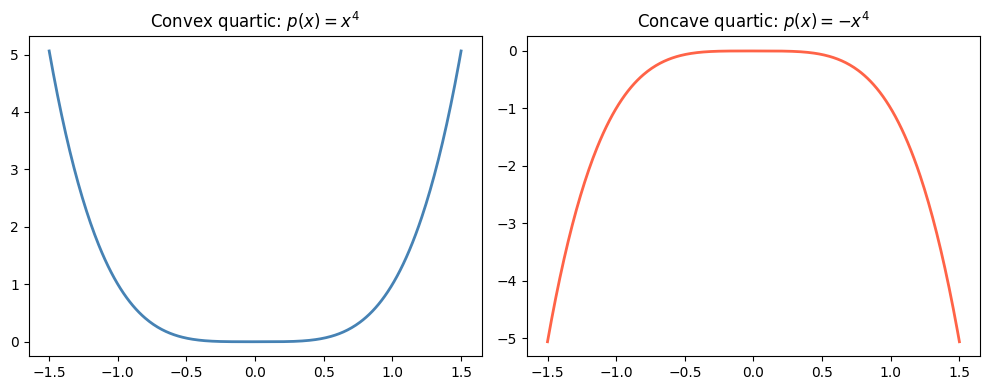

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data
x = np.linspace(-1.5, 1.5, 400)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: Convex
axes[0].plot(x, x**4, color='steelblue', lw=2)
axes[0].set_title(r'Convex quartic: $p(x) = x^4$') 
# Plot 2: Concave
axes[1].plot(x, -x**4, color='tomato', lw=2)
axes[1].set_title(r'Concave quartic: $p(x) = -x^4$')

# Adjust layout to prevent overlapping
plt.tight_layout()
# Display the plot inline instead of saving it
plt.show()

## Question 2: (Wireless Edge Inference Resource Allocation) (Mark 8 + 6 + 6 = 20 points)

In modern machine learning systems, edge devices (like smartphones or IoT sensors) often run neural network inference tasks locally and then transmit the results to a central server.

Consider an edge device that needs to process a machine learning inference task and transmit the output to a server. The total time available to complete both the computation and the transmission is strictly bounded by a latency deadline $T$.

The device can adjust its CPU frequency $f$ (in Hz) and its transmission time $t_{tx}$ (in seconds).

* The **computation energy** is given by $E_{comp} = c_1 f^2$, where $c_1$ is a hardware-specific capacitance constant.
* The **computation time** is given by $t_{comp} = c_3 f^{-1}$, where $c_3$ is the number of CPU cycles required to process the neural network.
* The **transmission energy** required to send the inference result reliably over the wireless channel is inversely proportional to the transmission time, given by $E_{tx} = c_2 t_{tx}^{-1}$, where $c_2$ is a channel-dependent constant.

**Your Tasks:**

1. Formulate the problem of minimizing the total energy consumption of the edge device subject to the latency deadline $T$ by identifying apporiate optimization variables, objective function, and constraints. Prove that your formulation is a valid Geometric Program in standard form.
2. In energy minimization problems, the latency constraint is typically "tight" at the optimal solution (meaning the device will use all the available time T to save energy). Assume $t_{comp}+t_{tx} =T$. Use this to express $t_{tx}$ in terms of $f$ and substitute it into the objective function to get the total energy strictly as a 1D function of $f$, denoted as $E(f)$. Determine the valid domain for $f$ and plot $E(f)$ over its valid domain up to $f=3$.
> Update per announcement: For plotting question of Q2.2, please use the following parameter values for the funtion $E(f)$: $c_1 = 1, c_2 = 2, c_3 = 1, T = 3$.
3. Let $c_1 = 10^{-18}$, $c_2 = 0.1$, $c_3 = 10^9$, and $T = 2.0$ seconds. Write a Python script using `cvxpy` to solve this Geometric Program formulated in 1. and find the optimal CPU frequency $f^*$, the optimal transmission time $t_{tx}^*$, and the minimum total energy.

[CVXPY](https://www.cvxpy.org/index.html) is an open source Python-embedded modeling language for convex optimization problems. This exercise aims to familiarze you with this package.


*Note: you are __not__ required to use CVXPY for your exercises or project. There are other Python-based optimization package you can use, including [Scipy](https://docs.scipy.org/doc/scipy/tutorial/optimize.html) or [Pyomo](https://www.pyomo.org/). If you decide to use a different optimization package, you can solve this exercise with one you choose. CVXPY lets you express your problem in a natural way that follows the math, rather than in the restrictive standard form required by solvers, but it has its own restrictions. In particular, CVXPY does not support non-convex optimization whereas other packages (e.g. Scipy) does.*


Before addressing this problem, we suggest you read through the first section of the [User Guide](https://www.cvxpy.org/tutorial/index.html) and a few [Basic examples](https://www.cvxpy.org/examples/index.html). They should already give you a pretty good idea how a convex optimization problem can be solved using CVXPY.




### Q2 Answers

---

#### Q2.1 Problem Formulation and GP Proof 


**Optimization variables:** $f > 0$ (CPU frequency in Hz), $\; t_{tx} > 0$ (transmission time in seconds).

**Objective:** Minimize total energy consumption:

$$
E(f, t_{tx}) = \underbrace{c_1 f^2}_{E_{comp}} + \underbrace{c_2 \, t_{tx}^{-1}}_{E_{tx}}
$$

**Constraints:**
- Latency deadline: $t_{comp} + t_{tx} \leq T$, i.e., $c_3 f^{-1} + t_{tx} \leq T$
- Implicit: $f > 0, \; t_{tx} > 0$ (required by the GP domain)

**Full formulation:**

$$
\begin{array}{ll}
\displaystyle\min_{f,\, t_{tx}} & c_1 f^2 + c_2 \, t_{tx}^{-1} \\[6pt]
\text{subject to} & c_3 f^{-1} + t_{tx} \leq T \\[4pt]
& f > 0, \quad t_{tx} > 0
\end{array}
$$

---

**Proof that this is a valid Geometric Program (GP):**

> **Geometric Programming (from lecture):**
>
> - **Monomial function:** $f(x) = c\, x_1^{a_1} x_2^{a_2} \cdots x_n^{a_n}$, $\;\mathbf{dom}\, f = \mathbb{R}_{++}^n$, where $c > 0$, $a_i \in \mathbb{R}$.
> - **Posynomial function:** sum of monomial functions, $\;\displaystyle\sum_{k=1}^{K} c_k\, x_1^{a_{1k}} \cdots x_n^{a_{nk}}$.
> - **Geometric program:**
>
> $$\begin{array}{ll} \text{minimize} & f_0(x) \\ \text{subject to} & f_i(x) \leq 1, \quad i = 1, \dots, m \\ & h_i(x) = 1, \quad i = 1, \dots, p \end{array}$$
>
> with $f_i$ (note: including objective) posynomial and $h_i$ monomial.

**Objective** $f_0 = c_1 f^2 + c_2 \, t_{tx}^{-1}$:
- $c_1 f^2 = c_1 \cdot f^{2} \cdot t_{tx}^{0}$ is a monomial (coefficient $c_1 > 0$, exponents $2, 0$).
- $c_2 \, t_{tx}^{-1} = c_2 \cdot f^{0} \cdot t_{tx}^{-1}$ is a monomial (coefficient $c_2 > 0$, exponents $0, -1$).
- Their sum is a **posynomial**. ✓

**Inequality constraint** — divide both sides by $T > 0$:

$$
\frac{c_3}{T} f^{-1} + \frac{1}{T} t_{tx} \leq 1
$$

- $\frac{c_3}{T} f^{-1}$ is a monomial (positive coefficient, exponents $-1, 0$).
- $\frac{1}{T} t_{tx}$ is a monomial (positive coefficient, exponents $0, 1$).
- Their sum is a **posynomial**, and the constraint has the form posynomial $\leq 1$. ✓

The remaining two implicit constraints are also mononial.

There are no equality constraints.

**Conclusion:** The objective is a posynomial being minimized and the only constraint is a posynomial $\leq 1$. Therefore, the formulation is a **valid Geometric Program in standard form**. $\blacksquare$


---

#### Q2.2 1D Reduction and Plot

Assuming the latency constraint is tight at the optimum: $t_{comp} + t_{tx} = T$, i.e.,

$$
c_3 f^{-1} + t_{tx} = T \quad \Longrightarrow \quad t_{tx} = T - \frac{c_3}{f}
$$

Substituting into the objective:

$$
E(f) = c_1 f^2 + c_2 \left(T - \frac{c_3}{f}\right)^{-1}
$$

**Valid domain for $f$:**
- We need $f > 0$ (physical requirement).
- We need $t_{tx} = T - c_3/f > 0$, which gives $f > c_3 / T$.

Therefore the valid domain is $f \in \left(\dfrac{c_3}{T},\; +\infty\right)$.

With $c_1 = 1,\; c_2 = 2,\; c_3 = 1,\; T = 3$: the domain is $f \in (1/3, +\infty)$, and we plot up to $f = 3$.

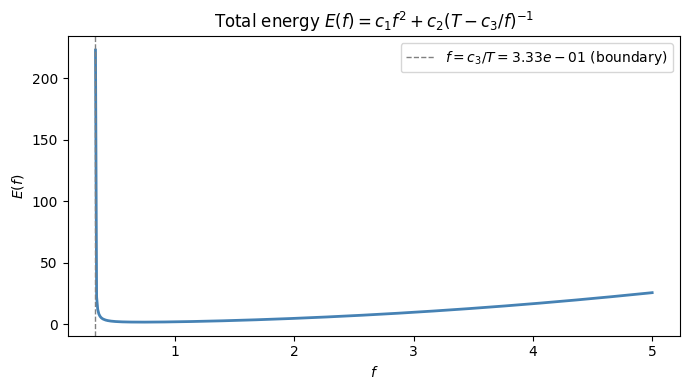

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_energy(c1, c2, c3, T, f_range=None, optimal_f=None):
    """Plot E(f) = c1*f^2 + c2/(T - c3/f) over the valid domain.
    
    Parameters
    ----------
    f_range : tuple (f_lo, f_hi), optional. Defaults to (c3/T + eps, 3).
    optimal_f : float, optional. If given, mark the optimal point on the plot.
    """
    f_min = c3 / T  # domain boundary
    if f_range is None:
        f_lo, f_hi = f_min + 1e-3, 3
    else:
        f_lo, f_hi = f_range

    f = np.linspace(f_lo, f_hi, 500)
    E = c1 * f**2 + c2 / (T - c3 / f)

    plt.figure(figsize=(7, 4))
    plt.plot(f, E, color='steelblue', lw=2)
    plt.axvline(f_min, color='grey', ls='--', lw=1,
                label=f'$f = c_3/T = {f_min:.2e}$ (boundary)')

    if optimal_f is not None:
        E_opt = c1 * optimal_f**2 + c2 / (T - c3 / optimal_f)
        plt.plot(optimal_f, E_opt, 'ro', ms=6, zorder=5, label=f'$f^* = {optimal_f:.4e}$')
        plt.axhline(E_opt, color='red', ls='-', lw=0.5, alpha=0.5,
                    label=f'$E^* = {E_opt:.4e}$')

    plt.xlabel('$f$')
    plt.ylabel('$E(f)$')
    plt.title(r'Total energy $E(f) = c_1 f^2 + c_2 \left(T - c_3/f\right)^{-1}$')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Q2.2 plot: c1=1, c2=2, c3=1, T=3, domain (1/3, 5]
plot_energy(c1=1, c2=2, c3=1, T=3, f_range=(1/3 + 1e-3, 5))


---

#### Q2.3 Solving the GP with CVXPY

Using $c_1 = 10^{-18}$, $c_2 = 0.1$, $c_3 = 10^9$, $T = 2.0$ s. Solve the GP formulated in Q2.1 to find optimal $f^*$, $t_{tx}^*$, and minimum total energy.

In [4]:
import cvxpy as cp

# Parameters
c1 = 1e-18
c2 = 0.1
c3 = 1e9
T  = 2.0

# Decision variables (positive, as required by GP)
f    = cp.Variable(pos=True, name="f")
t_tx = cp.Variable(pos=True, name="t_tx")

# Objective: minimize total energy
objective = cp.Minimize(c1 * f**2 + c2 * t_tx**(-1))

# Constraints
constraints = [c3 * f**(-1) + t_tx <= T]

# Solve as a Geometric Program
prob = cp.Problem(objective, constraints)
prob.solve(gp=True)

print(f"Status:              {prob.status}")
print(f"Optimal f*:          {f.value:.6e} Hz")
print(f"Optimal t_tx*:       {t_tx.value:.6f} s")
print(f"Minimum total energy: {prob.value:.6e}")

Status:              optimal
Optimal f*:          6.397747e+08 Hz
Optimal t_tx*:       0.436950 s
Minimum total energy: 6.381709e-01



**Double Check:**

We can also use the Q2.2's plotting code to confirm:

1. The latency constraint IS "tight" at the optimal solution.

2. Visualise the solution.

t_comp* = c3/f* = 1.563050 s
t_tx*           = 0.436950 s
t_comp* + t_tx* = 2.000000 s
T               = 2.000000 s
Constraint tight? True


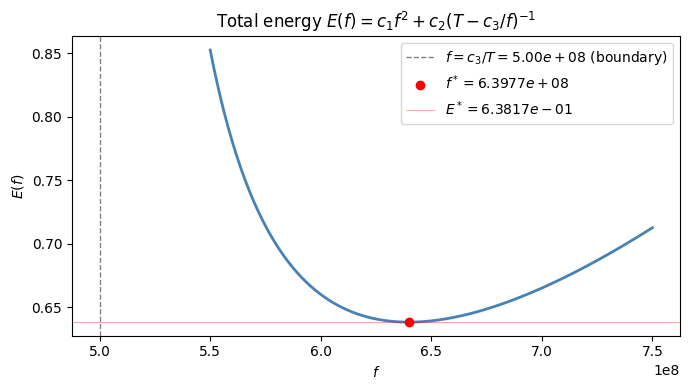

In [5]:
# Confirm the latency constraint is tight at the optimal solution
c1, c2, c3, T = 1e-18, 0.1, 1e9, 2.0
f_opt    = f.value
t_tx_opt = t_tx.value
t_comp_opt = c3 / f_opt

print(f"t_comp* = c3/f* = {t_comp_opt:.6f} s")
print(f"t_tx*           = {t_tx_opt:.6f} s")
print(f"t_comp* + t_tx* = {t_comp_opt + t_tx_opt:.6f} s")
print(f"T               = {T:.6f} s")
print(f"Constraint tight? {np.isclose(t_comp_opt + t_tx_opt, T)}")

# Visualise the optimal point on E(f)
plot_energy(c1, c2, c3, T,
            f_range=(5.5e8, 7.5e8),
            optimal_f=f_opt)

## Question 3 (Aloha communication protocol) (Mark: 3 + 15 + 2 = 20 points)

**Aloha** is a well-known random access or _MAC_ (Media/multiple Access Control) communication protocol. In this system, multiple independent transmitters send packets (called $\textit{frames}$) to a single receiver over a shared channel. In the original Aloha, each transmitter sends whenever it has data, without coordinating with others. If two or more packets overlap in time, a collision occurs and the packets are lost; the transmitters then retry after a random delay.

In a more advanced setup, called **slotted Aloha**, the nodes can only transmit at the beginning of time slots, which are kept by a global/shared clock. The operations of slotted ALOHA in each node are decribed as follows:

* If there is only one frame (namely only one active transmitter) in a slot, then the transmission is successful and the slot is said to be a successful slot.
* If two or more frames (namely two or more active transmitters) collide in a slot, then the transmission is failed and a re-transmission is considered for each frame involved in the collision. The transmitter will retransmit its frame in each subsequent slot with probability $p$ until the frame is transmitted without a collision, where $0 \leq p \leq 1$.

Assume that there are $N$ transmitters and each transmitter independently attempts to transmit a frame in each slot with probability $p$. For one slot, let $S$ denote the _success probability_ that this slot is a successful slot.

Answer the following questions:
1. Provide an expression of $S$ defined above.
2. To maximise the $S$, define the optimisation problem to find the optimal value $p$. Note that the constraint $0 \leq p \leq 1$
should be taken into consideration. Clearly identify the objective and decision variable(s). Is the objective convex or concave? Show through derivation. Find the optimality conditions for this problem.
3. When $N$ tends to infinity, what is the maximal success probability $S$?

### Q3 Answers

---

#### Q3.1 Expression for the Success Probability $S$

A slot is successful if and only if **exactly one** of the $N$ transmitters transmits in that slot.

Each transmitter independently transmits with probability $p$, so the number of transmitters active in a slot follows a $\text{Binomial}(N, p)$ distribution. The success probability is therefore:

> "A Binomial distribution models the total number of successes across multiple independent Bernoulli trials."

$$
S = P(\text{exactly 1 transmitter active}) = \binom{N}{1} p^1 (1-p)^{N-1}
$$

$$
\boxed{S = N p (1-p)^{N-1}}
$$

---

#### Q3.2 Optimisation Problem, Concavity, and Optimality Conditions

**Decision variable:** $p \in [0, 1]$ (transmission probability).

**Optimisation problem:**

$$
\begin{array}{ll}
\displaystyle\max_{p} & S(p) = N p (1-p)^{N-1} \\
\text{subject to} & 0 \leq p \leq 1
\end{array}
$$

##### First derivative

Using the product rule on $S(p) = Np \cdot (1-p)^{N-1}$:

$$
S'(p) = N(1-p)^{N-1} + Np \cdot (-(N-1))(1-p)^{N-2}
= N(1-p)^{N-2}\big[(1-p) - (N-1)p\big]
$$

$$
\boxed{S'(p) = N(1-p)^{N-2}(1 - Np)}
$$

##### Concavity analysis (second derivative)

Applying the product rule to $S'(p) = N(1-p)^{N-2}(1-Np)$:

$$
S''(p) = N\Big[-(N-2)(1-p)^{N-3}(1-Np) + (1-p)^{N-2}(-N)\Big]
$$

$$
= N(1-p)^{N-3}\Big[-(N-2)(1-Np) - N(1-p)\Big]
$$

Expanding the bracket:

$$
-(N-2) + N(N-2)p - N + Np = -2(N-1) + N(N-1)p = (N-1)(Np - 2)
$$

$$
\boxed{S''(p) = N(N-1)(1-p)^{N-3}(Np - 2)}
$$

For $p \in [0, 1)$ and $N \geq 2$, the prefactor $N(N-1)(1-p)^{N-3} > 0$, so the sign of $S''$ is determined by $(Np - 2)$:

- $S''(p) \leq 0$ when $p \leq \dfrac{2}{N}$ — **$S$ is concave on $\left[0,\, \dfrac{2}{N}\right]$**.
- $S''(p) > 0$ when $p > \dfrac{2}{N}$ — $S$ is convex on $\left(\dfrac{2}{N},\, 1\right)$.

For $N = 2$: $S''(p) = -4 < 0$ for all $p \in (0,1)$, so $S$ is **strictly concave** on $[0,1]$.

For $N \geq 3$: $S$ is **not globally concave** on $[0, 1]$, but is concave on $[0, 2/N]$, which contains the optimal point $p^* = 1/N$ (derived below).

##### Finding the global maximum

Setting $S'(p) = 0$:

$$
N(1-p)^{N-2}(1 - Np) = 0
$$

This gives two solutions: $p = 1$ or $p = 1/N$.

$S$ is continuous on the closed bounded interval $[0, 1]$, so by the **Extreme Value Theorem** the global maximum must occur at a critical point or a boundary. We compare all candidates:

| Point | Type | $S$ value |
|-------|------|-----------|
| $p = 0$ | Boundary | $S(0) = 0$ |
| $p = 1/N$ | Critical point | $S(1/N) = \left(\frac{N-1}{N}\right)^{N-1} > 0$ |
| $p = 1$ | Critical point / Boundary | $S(1) = N \cdot 1 \cdot 0^{N-1} = 0$ |

Since $S(1/N) > 0 = S(0) = S(1)$, the **global maximum** is:

$$
\boxed{p^* = \frac{1}{N}, \qquad S^* = \left(\frac{N-1}{N}\right)^{N-1}}
$$

This is further confirmed by the second derivative at $p^*$:

$$
S''\!\left(\tfrac{1}{N}\right) = N(N-1)\left(\tfrac{N-1}{N}\right)^{N-3}(1 - 2) = -N(N-1)\left(\tfrac{N-1}{N}\right)^{N-3} < 0
$$

> **Remark (KKT approach).** Alternatively, one can verify the optimality conditions using the KKT framework. Rewrite as $\min_p -S(p)$ subject to $-p \leq 0$ and $p - 1 \leq 0$, with Lagrangian
>
> $$L(p, \lambda_1, \lambda_2) = -S(p) - \lambda_1 p + \lambda_2(p - 1)$$
>
> **KKT conditions:** (1) Stationarity: $-S'(p^*) - \lambda_1 + \lambda_2 = 0$; (2) Complementary slackness: $\lambda_1 p^* = 0$, $\lambda_2(p^* - 1) = 0$; (3) Dual feasibility: $\lambda_1, \lambda_2 \geq 0$; (4) Primal feasibility: $0 \leq p^* \leq 1$.
>
> At $p^* = 1/N$ (interior point), both constraints are inactive, so $\lambda_1 = \lambda_2 = 0$. Stationarity reduces to $S'(p^*) = 0$, which is satisfied.


---

#### Q3.3 Limiting Success Probability as $N \to \infty$

From Q3.2, the maximal success probability at $p^* = 1/N$ is:

$$
S^* = \left(\frac{N-1}{N}\right)^{N-1} = \left(1 - \frac{1}{N}\right)^{N-1}
$$

Rewrite by separating the exponent:

$$
S^* = \left(1 - \frac{1}{N}\right)^{N} \cdot \left(1 - \frac{1}{N}\right)^{-1}
$$

Taking the limit as $N \to \infty$:

- $\displaystyle\lim_{N \to \infty} \left(1 - \frac{1}{N}\right)^{N} = e^{-1}$ — by the definition of Euler's number.
- $\displaystyle\lim_{N \to \infty} \left(1 - \frac{1}{N}\right)^{-1} = 1$.

Therefore:

$$
\boxed{\lim_{N \to \infty} S^* = \frac{1}{e} \approx 0.368}
$$

This is a classical result: even with an optimal transmission strategy, slotted Aloha can utilise at most about **36.8%** of the channel capacity as the number of transmitters grows large.

---


## Question 4 (Geometric programming: power control in wireless network) (Mark: 3 + 7 + 6 + 4 = 20 points)

### Example: Power Control in Wireless Communication

 *Adapted from Boyd, Kim, Vandenberghe, and Hassibi,* "[A Tutorial on Geometric Programming](https://web.stanford.edu/~boyd/papers/pdf/gp_tutorial.pdf)."

The [power control problem in wireless communications](http://winlab.rutgers.edu/~narayan/PAPERS/PC%20for%20Wireless%20Data.pdf) aims to minimise the total transmitter power available across $N$ trasmitters while concurrently achieving good (or a pre-defined minimum) performance.

The technical setup is as follows. Each transmitter $i$ transmits with a power level $P_i$ bounded below and above by a minimum and maximum level. The power of the signal received from transmitter $j$ at receiver $i$ is $G_{ij} P_{j}$, where $G_{ij} > 0$ represents the path gain (often loss) from transmitter $j$ to receiver $i$. The signal power at the intended receiver $i$ is $G_{ii} P_i$, and the interference power at receiver $i$ from other transmitters is given by $\sum_{k \neq i} G_{ik}P_k$. The (background) noise power at receiver $i$ is $\sigma_i$. Thus, the _Signal to Interference and  Noise Ratio (SINR)_ of the $i$-th receiver-transmitter pair is

$$ S_i = \frac{G_{ii}P_i}{\sum_{k \neq i} G_{ik}P_k + \sigma_i }. $$

The minimum SINR represents a performance lower bound for this system, $S^{\text min}$.

The resulting optimisation problem is formulated as

$$
\begin{array}{ll}
\min_{P} & \sum_{i=1}^N P_i \\
\text{subject to} & P^{min} \leq P_i \leq P^{max}, \; \forall i \\
& \dfrac{G_{ii}P_i}{\sigma_i + \sum_{k \neq i} G_{ik}P_k} \geq S^{min} , \; \forall i \\
\end{array}
$$

### Answer the following questions: Wireless Power Control

Let $N=10$, $P^{min}=0.1$, $P^{max}=5$, $\sigma=0.2$ (same for all). Create a random path loss matrix $G$, where off-diagonal elements are between $0.1$ and $0.9$ and the diagonal elements are equal to $1$.
1. Convert the problem into standard Geometric Programming form.
2. Solve the problem first with $S^{min}=0$, and we recommand to use *cvxpy* or *scipy*. Output and plot the power levels and SINRs that you obtain.
3. What happens if you choose an $S^{min}$ that is larger? Solve the problem again and document your results. What happens if you choose a very large $S^{min}$? Observe and comment.
4. Suppose that there are only 3 transmitter-receiver pairs, e.g., $N=3$, if the SINR of the $i$-th receiver-transmitter pair is

$$ S_i = \frac{G_{ii}P_i}{0.5 \sum_{j \neq i}^{N} (G_{ij} P_j \sum_{k \neq i, k \neq j}^{N} G_{ik} P_k )+ \sigma_i }. $$

and other settings remain the same, please try to convert the problem into standard Geometric Programming form again.

**Note:**
* if you are in the minority of people who have problem installing *cvxpy* or *scipy*, then you can use other packages or even Matlab.
* the problem in (1) can be converted to either Geometric Programming or Linear Programming form, while the problem in (4) can not be converted to Linear Programming anymore.

### Q4 Answers

---

#### Q4.1 Converting to Standard Geometric Programming Form

A **Geometric Program (GP)** in standard form is:

$$
\begin{array}{ll}
\min & f_0(\mathbf{x}) \\
\text{subject to} & f_i(\mathbf{x}) \leq 1, \quad i = 1, \dots, m \\
& g_j(\mathbf{x}) = 1, \quad j = 1, \dots, p
\end{array}
$$

where $f_0, f_i$ are **posynomials** and $g_j$ are **monomials**.

We convert each part of the original problem.

##### Objective

The objective $\displaystyle\sum_{i=1}^N P_i$ is a sum of monomials with positive coefficients — a **posynomial**. Valid as a GP objective.

##### Power bound constraints

The box constraints $P^{\min} \leq P_i \leq P^{\max}$ are rewritten as:

$$
\frac{P_i}{P^{\max}} \leq 1, \qquad \frac{P^{\min}}{P_i} \leq 1, \qquad \forall\, i
$$

Each left-hand side is a **monomial** in $P_i$ (a special case of posynomial), so these are valid GP constraints.

##### SINR constraints

The SINR requirement $\dfrac{G_{ii}P_i}{\sigma_i + \sum_{k \neq i} G_{ik}P_k} \geq S^{\min}$ is rearranged by inverting both sides (the ratio is positive, so the inequality flips):

$$
\frac{\sigma_i + \sum_{k \neq i} G_{ik}P_k}{G_{ii}P_i} \leq \frac{1}{S^{\min}}
$$

Multiplying both sides by $S^{\min}$ and distributing:

$$
\frac{S^{\min} \sigma_i}{G_{ii}} P_i^{-1} \;+\; \sum_{k \neq i} \frac{S^{\min} G_{ik}}{G_{ii}} P_k P_i^{-1} \;\leq\; 1
$$

The left-hand side is a sum of terms of the form $c \cdot P_k^{a_k} P_i^{-1}$ where all coefficients $c > 0$ and the exponents are integers. Each term is a **monomial**, and their sum is a **posynomial**. This is therefore a valid GP inequality constraint.

##### Summary: Standard GP Form

$$
\boxed{
\begin{array}{ll}
\displaystyle\min_{\mathbf{P}} & \displaystyle\sum_{i=1}^N P_i \\[6pt]
\text{subject to} & \dfrac{S^{\min} \sigma_i}{G_{ii}} P_i^{-1} + \displaystyle\sum_{k \neq i} \dfrac{S^{\min} G_{ik}}{G_{ii}} P_k P_i^{-1} \leq 1, \quad \forall\, i \\[6pt]
& P^{\min} P_i^{-1} \leq 1, \quad \forall\, i \\[6pt]
& P_i \left(P^{\max}\right)^{-1} \leq 1, \quad \forall\, i
\end{array}
}
$$

All constraints are posynomials $\leq 1$ and the objective is a posynomial, confirming this is a valid GP.


---

#### Q4.2 Solving the GP with $S^{\min}=0$

When $S^{\min}=0$, the SINR constraints are **trivially satisfied** (any positive power gives $S_i \geq 0$). The problem reduces to minimising $\sum P_i$ subject only to the box constraints, so the optimal solution is clearly $P_i^* = P^{\min}$ for all $i$.

We solve this with `cvxpy` in GP mode to verify, and then compute and plot the resulting power levels and SINRs.

Path-loss matrix G:
[[1.    0.641 0.441 0.726 0.731 0.129 0.818 0.708 0.268 0.635]
 [0.217 1.    0.417 0.684 0.135 0.544 0.246 0.275 0.62  0.165]
 [0.616 0.733 1.    0.106 0.45  0.535 0.865 0.503 0.599 0.499]
 [0.282 0.234 0.852 1.    0.426 0.886 0.312 0.765 0.636 0.13 ]
 [0.324 0.654 0.251 0.796 1.    0.554 0.87  0.447 0.568 0.555]
 [0.211 0.508 0.222 0.191 0.584 1.    0.245 0.131 0.137 0.687]
 [0.774 0.419 0.112 0.498 0.608 0.663 1.    0.158 0.705 0.603]
 [0.344 0.478 0.189 0.162 0.568 0.87  0.47  1.    0.518 0.425]
 [0.873 0.213 0.37  0.779 0.745 0.604 0.612 0.145 1.    0.465]
 [0.401 0.395 0.188 0.281 0.241 0.597 0.86  0.166 0.513 1.   ]]
S_min = 0.0: Total power = 1.0000, P = [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1], SINR = [0.1409 0.1886 0.1448 0.1533 0.1425 0.2034 0.1529 0.166  0.147  0.1773]


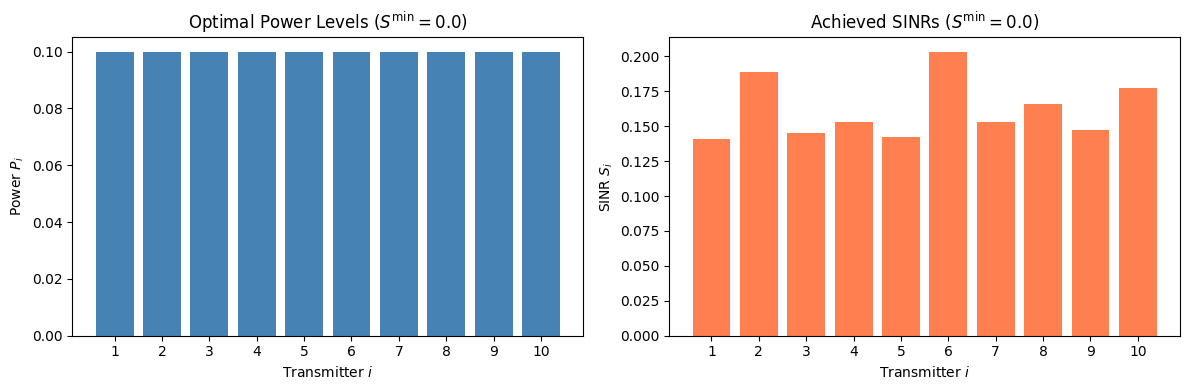

In [6]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# ---------- Parameters ----------
N = 10
P_min_val, P_max_val = 0.1, 5.0
sigma = 0.2

# Random path-loss matrix G (fixed seed for reproducibility)
np.random.seed(114514)
G = np.random.uniform(0.1, 0.9, size=(N, N))
np.fill_diagonal(G, 1.0)
print("Path-loss matrix G:")
print(np.round(G, 3))


def solve_power_control(G, S_min_val, sigma=0.2, P_min_val=0.1, P_max_val=5.0, plot=True):
    """Solve the GP power control problem and optionally plot results."""
    N = G.shape[0]
    P = cp.Variable(N, pos=True)

    objective = cp.Minimize(cp.sum(P))

    constraints = []
    for i in range(N):
        constraints.append(P[i] >= P_min_val)
        constraints.append(P[i] <= P_max_val)
        if S_min_val > 0:
            lhs = (S_min_val * sigma / G[i, i]) * P[i]**(-1)
            for k in range(N):
                if k != i:
                    lhs += (S_min_val * G[i, k] / G[i, i]) * P[k] * P[i]**(-1)
            constraints.append(lhs <= 1)

    prob = cp.Problem(objective, constraints)
    try:
        prob.solve(gp=True)
    except cp.SolverError:
        print(f"S_min = {S_min_val}: Solver failed (infeasible).")
        return None, None, prob.status

    if prob.status != 'optimal':
        print(f"S_min = {S_min_val}: Status = {prob.status}")
        return None, None, prob.status

    P_opt = P.value
    sinr = np.zeros(N)
    for i in range(N):
        interference = sum(G[i, k] * P_opt[k] for k in range(N) if k != i)
        sinr[i] = G[i, i] * P_opt[i] / (sigma + interference)

    print(f"S_min = {S_min_val}: Total power = {prob.value:.4f}, "
          f"P = {np.round(P_opt, 4)}, SINR = {np.round(sinr, 4)}")

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].bar(range(1, N+1), P_opt, color='steelblue')
        axes[0].set_xlabel('Transmitter $i$')
        axes[0].set_ylabel('Power $P_i$')
        axes[0].set_title(f'Optimal Power Levels ($S^{{\\min}}={S_min_val}$)')
        axes[0].set_xticks(range(1, N+1))

        axes[1].bar(range(1, N+1), sinr, color='coral')
        axes[1].set_xlabel('Transmitter $i$')
        axes[1].set_ylabel('SINR $S_i$')
        axes[1].set_title(f'Achieved SINRs ($S^{{\\min}}={S_min_val}$)')
        axes[1].set_xticks(range(1, N+1))

        plt.tight_layout()
        plt.show()

    return P_opt, sinr, prob.status


# ---------- Solve with S_min = 0 ----------
P_opt, sinr, status = solve_power_control(G, S_min_val=0.0)


---

#### Q4.3 Effect of Increasing $S^{\min}$

As $S^{\min}$ increases, each transmitter must boost its own power to meet the SINR floor — but doing so **raises interference for every other receiver**, forcing them to increase power as well. This creates a **positive-feedback** loop that quickly drives powers toward $P^{\max}$. (We will this a huge rise of Tx power in the following plot.)

Beyond a critical threshold $S^{\min}_\text{max}$, no feasible power allocation exists within the box constraints — the problem becomes **infeasible**. We demonstrate this below by:

1. Solving for several increasing values of $S^{\min}$.
2. Using bisection to find $S^{\min}_\text{max}$ to three decimal places.

S_min = 0.0: Total power = 1.0000, P = [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1], SINR = [0.1409 0.1886 0.1448 0.1533 0.1425 0.2034 0.1529 0.166  0.147  0.1773]
S_min = 0.05: Total power = 1.0000, P = [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1], SINR = [0.1409 0.1886 0.1448 0.1533 0.1425 0.2034 0.1529 0.166  0.147  0.1773]
S_min = 0.1: Total power = 1.0000, P = [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1], SINR = [0.1409 0.1886 0.1448 0.1533 0.1425 0.2034 0.1529 0.166  0.147  0.1773]
S_min = 0.15: Total power = 1.0230, P = [0.1076 0.1    0.1051 0.1    0.1062 0.1    0.1001 0.1    0.1041 0.1   ], SINR = [0.15   0.1861 0.15   0.1506 0.15   0.2006 0.15   0.1635 0.15   0.1749]
S_min = 0.175: Total power = 1.3684, P = [0.1567 0.1149 0.1508 0.1423 0.1525 0.1047 0.1436 0.1289 0.1519 0.1222], SINR = [0.175 0.175 0.175 0.175 0.175 0.175 0.175 0.175 0.175 0.175]
S_min = 0.2: Total power = 2.6657, P = [0.3108 0.2183 0.2973 0.2785 0.3009 0.195  0.2817 0.2482 0.3007 0.2342], SINR = [0.2 0.2 0.2 0.2 0.2 0

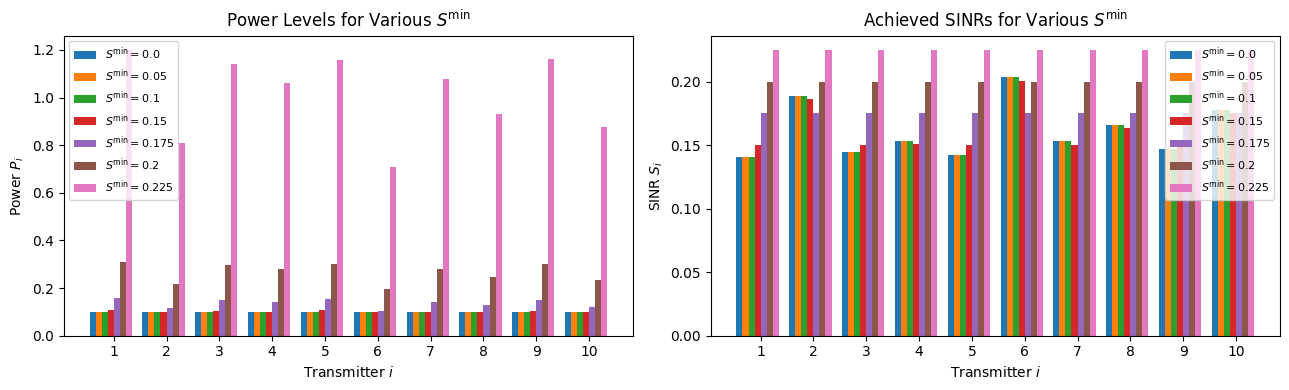

S_min = 0.5: Status = infeasible
S_min = 0.25: Status = infeasible
S_min = 0.125: Total power = 1.0000, P = [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1], SINR = [0.1409 0.1886 0.1448 0.1533 0.1425 0.2034 0.1529 0.166  0.147  0.1773]
S_min = 0.1875: Total power = 1.8482, P = [0.2136 0.1533 0.2049 0.1927 0.2073 0.1383 0.1946 0.1731 0.2068 0.1637], SINR = [0.1875 0.1875 0.1875 0.1875 0.1875 0.1875 0.1875 0.1875 0.1875 0.1875]
S_min = 0.21875: Total power = 6.1742, P = [0.7294 0.4959 0.6947 0.6473 0.7033 0.4364 0.6562 0.57   0.7052 0.536 ], SINR = [0.2187 0.2188 0.2188 0.2188 0.2187 0.2188 0.2187 0.2188 0.2188 0.2188]
S_min = 0.234375: Status = infeasible
S_min = 0.2265625: Total power = 11.9619, P = [1.4207 0.953  1.3508 1.2557 1.3677 0.8331 1.2743 1.1001 1.3734 1.0331], SINR = [0.2266 0.2266 0.2266 0.2266 0.2266 0.2266 0.2266 0.2266 0.2266 0.2266]
S_min = 0.23046875: Total power = 21.5430, P = [2.5656 1.7093 2.4372 2.263  2.4678 1.4892 2.2976 1.9775 2.4799 1.856 ], SINR = [0.2305 0.2305 0.2

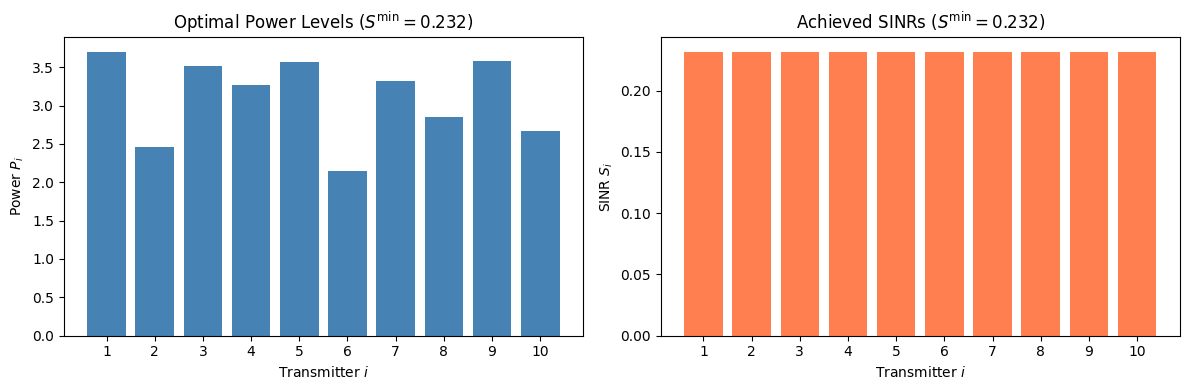

(array([3.70385968, 2.46121208, 3.51721176, 3.26439408, 3.56140931,
        2.14136991, 3.31496241, 2.84971881, 3.5799324 , 2.67391981]),
 array([0.232, 0.232, 0.232, 0.232, 0.232, 0.232, 0.232, 0.232, 0.232,
        0.232]),
 'optimal')

In [7]:
# ---------- Solve for several S_min values ----------
S_min_values = [0.0, 0.05, 0.10, 0.15, 0.175, 0.20, 0.225, 0.25, 0.30, 0.50, 1.0]

results = []
for s in S_min_values:
    P_opt, sinr, status = solve_power_control(G, S_min_val=s, plot=False)
    results.append((s, P_opt, sinr, status))

# Plot feasible cases side by side
feasible = [(s, P_opt, sinr) for s, P_opt, sinr, st in results if st == 'optimal']

if feasible:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    width = 0.8 / len(feasible)
    for j, (s, P_opt, sinr) in enumerate(feasible):
        x = np.arange(1, N+1) + (j - len(feasible)/2) * width
        axes[0].bar(x, P_opt, width=width, label=f'$S^{{\\min}}={s}$')
        axes[1].bar(x, sinr, width=width, label=f'$S^{{\\min}}={s}$')

    axes[0].set_xlabel('Transmitter $i$')
    axes[0].set_ylabel('Power $P_i$')
    axes[0].set_title('Power Levels for Various $S^{\\min}$')
    axes[0].set_xticks(range(1, N+1))
    axes[0].legend(fontsize=8)

    axes[1].set_xlabel('Transmitter $i$')
    axes[1].set_ylabel('SINR $S_i$')
    axes[1].set_title('Achieved SINRs for Various $S^{\\min}$')
    axes[1].set_xticks(range(1, N+1))
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# ---------- Bisection to find largest feasible S_min ----------
lo, hi = 0.0, 1.0
while hi - lo > 0.001:
    mid = (lo + hi) / 2
    _, _, status = solve_power_control(G, S_min_val=mid, plot=False)
    if status == 'optimal':
        lo = mid
    else:
        hi = mid

print(f"\nLargest feasible S_min (to 3 decimal places): {lo:.3f}")

# Show the solution at the threshold
print(f"\n--- Solution at S_min = {lo:.3f} ---")
solve_power_control(G, S_min_val=round(lo, 3))


---

#### Q4.4 Nonlinear SINR — GP Formulation for $N=3$

The modified SINR for receiver $i$ is:

$$
S_i = \frac{G_{ii}P_i}{0.5 \displaystyle\sum_{j \neq i} \left( G_{ij}P_j \sum_{k \neq i,\, k \neq j} G_{ik}P_k \right) + \sigma_i}
$$

##### Expanding the denominator for $N = 3$

For receiver $i$, the double sum has terms $(j, k)$ where $j \neq i$ and $k \neq i, k \neq j$. With $N=3$ there are exactly **two** such ordered pairs, which are symmetric:

| Receiver $i$ | $(j, k)$ pairs | Interference (after $\times 0.5$) |
|:---:|:---:|:---:|
| 1 | $(2,3),\;(3,2)$ | $G_{12}G_{13}P_2P_3$ |
| 2 | $(1,3),\;(3,1)$ | $G_{21}G_{23}P_1P_3$ |
| 3 | $(1,2),\;(2,1)$ | $G_{31}G_{32}P_1P_2$ |

So each SINR simplifies to:

$$
S_1 = \frac{G_{11}P_1}{G_{12}G_{13}P_2P_3 + \sigma}, \quad
S_2 = \frac{G_{22}P_2}{G_{21}G_{23}P_1P_3 + \sigma}, \quad
S_3 = \frac{G_{33}P_3}{G_{31}G_{32}P_1P_2 + \sigma}
$$

##### Converting the SINR constraint to GP form

Taking the constraint $S_i \geq S^{\min}$ and rearranging (same approach as Q4.1 — invert and multiply by $S^{\min}$):

$$
\frac{S^{\min}\sigma}{G_{ii}} P_i^{-1} \;+\; \frac{S^{\min} G_{ij} G_{ik}}{G_{ii}} P_j P_k P_i^{-1} \;\leq\; 1, \qquad \forall\, i
$$

where $\{j, k\} = \{1, 2, 3\} \setminus \{i\}$ (excluding $i$), and $j \neq k$.

Each term is a **monomial** (positive coefficient $\times$ product of variables to integer powers):
- $\frac{S^{\min}\sigma}{G_{ii}} P_i^{-1}$: monomial in $P_i$
- $\frac{S^{\min} G_{ij} G_{ik}}{G_{ii}} P_j^1 P_k^1 P_i^{-1}$: monomial in $P_i, P_j, P_k$

Their sum is a **posynomial**, so the constraint has the form posynomial $\leq 1$. Valid for GP.

##### Standard GP form for $N = 3$

$$
\boxed{
\begin{array}{ll}
\displaystyle\min_{P_1, P_2, P_3} & P_1 + P_2 + P_3 \\[6pt]
\text{subject to} & \dfrac{S^{\min}\sigma}{G_{ii}} P_i^{-1} + \dfrac{S^{\min} G_{ij} G_{ik}}{G_{ii}} P_j P_k P_i^{-1} \leq 1, \quad \forall\, i \\[6pt]
& P^{\min} P_i^{-1} \leq 1, \quad \forall\, i \\[6pt]
& P_i (P^{\max})^{-1} \leq 1, \quad \forall\, i
\end{array}
}
$$

> **Remark (GP vs LP).** 
> 
> The original SINR constraint (Q4.1) can be rearranged by multiplying both sides by the denominator:
>
> $$G_{ii}P_i - S^{\min}\sum_{k \neq i} G_{ik}P_k \geq S^{\min}\sigma$$
>
> This is **linear** in $P$, so the original problem is both a GP and an LP.
>
> Here, the same rearrangement gives $G_{ii}P_i - S^{\min}G_{ij}G_{ik}P_jP_k \geq S^{\min}\sigma$, which contains the **product** $P_jP_k$ — inherently nonlinear. This problem is a valid GP, but **cannot** be reduced to an LP. This is precisely the distinction the question note highlights.

---


## Question 5 (Gradient descent for Logistic Regression) (Mark: 5 + 10 + 5 = 20 points)



### Background
Suppose we are given a binary classification dataset consisting of $n$ independent samples $S=\{(\mathbf{x}_i,y_i)\}^n_{i=1}$, where $\mathbf x_i∈\mathbb R^d$ represents the feature vector of the $i$-th sample and $y_i∈\{0,1\}$ is the corresponding label.


Logistic regression models the probability of the event $Y=1$ given the feature vector $\mathbf x$. Specifically, logistic regression assumes a linear relationship between the features $\mathbf{x}$ and the log-odds of the event $Y = 1$:

$$
\log \frac{p(y = 1|\mathbf{x})}{1 - p(y = 1|\mathbf{x})} = \mathbf{x}^\top \mathbf{w},
$$
where $\mathbf w\in \mathbb R^d$ is the weight vector.

> [!NOTE]
> 
> Log odds are the natural logarithm of the odds, representing the probability of an event occurring relative to it not occurring. 
> 
> This transformation maps probabilities from the 0–1 range to a scale of negative to positive infinity, enabling linear modeling in logistic regression.

Given the dataset, we estimate the weight vector $\mathbf w$ by minimizing the empirical risk under the log-loss (also known as cross-entropy loss):

$$
\hat{R}(\mathbf{w}) = - \frac{1}{n} \sum_{i = 1}^{n} \ell_\mathrm{log}(y_i, \mu_i(\mathbf{w})),
$$

where $\ell_\mathrm{log}(y, \mu) = y \log \mu + (1 - y) \log (1 - \mu)$.

In this exercise you will:

* derive the gradient,
* implement gradient descent from scratch,
* verify correctness by comparing with a standard library implementation.

> An additional background remark for Q5: 
>
> $\mu_i(\mathbf{w})$ is the model's predicted probability that the $i$-th sample belongs to class 1, given the parameter $\mathbf{w}$.

---





### 5.1 — Mathematical Derivation

**1.** Given the expression of $\mu_i(\mathbf{w}):=?$

**2.** Give the expression the gradient of the empirical risk at iteration $t$
$$
\nabla_{\mathbf{w}} \hat{R}(\mathbf{w}_t)=  ?
$$

---

**3.** Using a fixed learning rate ($\eta>0$), write the gradient descent update rule at iteration $t+1$

$$
\mathbf{w}_{t+1} =  ?
$$

Clearly specify all quantities appearing in the update, and note that $\mathbf{w},\mathbf x_i∈\mathbb{R}^{d}.$

---

#### Answers - Q5.1.1

From the log-odds definition:

$$
\log \frac{\mu_i}{1 - \mu_i} = \mathbf{x}_i^\top \mathbf{w}
\quad\Longrightarrow\quad
\frac{\mu_i}{1 - \mu_i} = e^{\mathbf{x}_i^\top \mathbf{w}}
\quad\Longrightarrow\quad
\boxed{\mu_i(\mathbf{w}) = \frac{1}{1 + e^{-\mathbf{x}_i^\top \mathbf{w}}} = \sigma(\mathbf{x}_i^\top \mathbf{w})}
$$

where $\sigma(z) = \frac{1}{1+e^{-z}}$ is the sigmoid function.

#### Answers - Q5.1.2

The empirical risk is:

$$
\hat{R}(\mathbf{w}) = -\frac{1}{n}\sum_{i=1}^{n}\bigl[y_i \log \mu_i + (1-y_i)\log(1-\mu_i)\bigr]
$$

Using the chain rule with the sigmoid derivative $\frac{\partial \mu_i}{\partial \mathbf{w}} = \mu_i(1-\mu_i)\,\mathbf{x}_i$:

> $$
> \frac{\partial \mu_i}{\partial \mathbf{w}} = \frac{\mathbf{x}_i e^{-\mathbf{x}_i^\top \mathbf{w}}}{(1 + e^{-\mathbf{x}_i^\top \mathbf{w}})^2} = \mathbf{x}_i \cdot \frac{1-\mu_i}{\mu_i}\cdot \mu_i^2
> $$

$$
\frac{\partial}{\partial \mathbf{w}}\bigl[y_i\log\mu_i + (1-y_i)\log(1-\mu_i)\bigr]
= \left(\frac{y_i}{\mu_i} - \frac{1-y_i}{1-\mu_i}\right)\mu_i(1-\mu_i)\,\mathbf{x}_i
= (y_i - \mu_i)\,\mathbf{x}_i
$$

Therefore:

$$
\boxed{\nabla_{\mathbf{w}}\hat{R}(\mathbf{w}_t) = \frac{1}{n}\sum_{i=1}^{n}\bigl(\mu_i(\mathbf{w}_t) - y_i\bigr)\,\mathbf{x}_i = \frac{1}{n}\mathbf{X}^\top\bigl(\boldsymbol{\mu}(\mathbf{w}_t) - \mathbf{y}\bigr)}
$$

where $\boldsymbol{\mu}(\mathbf{w}_t) = [\mu_1(\mathbf{w}_t),\dots,\mu_n(\mathbf{w}_t)]^\top$ and $\mathbf{X}\in\mathbb{R}^{n\times d}$ is the data matrix.

> [!NOTE]
>
> Check: Dimension matches.

#### Answers - Q5.1.3

> Refer: Slides 6. Linear Regression
> 
> **Algorithm 2** Gradient descent for logistic regression
>
> **Require:** an initial point $\mathbf{w}^{(0)}$, data $\{\mathbf{x}_i, y_i\}_{i=1,\dots,n}$, step size $t$
>
> 1. **while** stopping criterion not satisfied **do**
> 2. $\quad \nabla f(\mathbf{w}^{(k)}) := \sum_{i=1}^{n} \mathbf{x}_{(i)} \bigl(\sigma(\mathbf{w}^{(k)\top} \mathbf{x}_i) - y_i\bigr)$
> 3. $\quad$ update $\mathbf{w}^{(k+1)} = \mathbf{w}^{(k)} - t \nabla f(\mathbf{w}^{(k)})$
> 4. **end while**

The gradient descent update rule with fixed learning rate $\eta > 0$:

$$
\boxed{\mathbf{w}_{t+1} = \mathbf{w}_t - \eta\,\nabla_{\mathbf{w}}\hat{R}(\mathbf{w}_t) = \mathbf{w}_t - \frac{\eta}{n}\sum_{i=1}^{n}\bigl(\mu_i(\mathbf{w}_t) - y_i\bigr)\,\mathbf{x}_i}
$$

where $\mu_i(\mathbf{w}_t) = \sigma(\mathbf{x}_i^\top \mathbf{w}_t)$, $\mathbf{w}_t, \mathbf{x}_i \in \mathbb{R}^d$, and $\eta > 0$ is the learning rate.


---



### 5.2 — Programming Implementation 

You will now implement logistic regression trained using **batch gradient descent**.

Write a function ``fit_logistic(X, y, w_init, max_iter, tol, update_weight)``

that returns the learned parameter $\mathbf{w}$.

### Requirements

Your implementation should contain the following components:

---

### (a) Empirical risk function 

The function ``risk(X, y, w)``

that computes empircal risk under the log-loss.

---

### (b) Gradient function 

The function  ``grad_risk(X, y, w)``

that computes $\nabla_{\mathbf{w}} \hat{R}(\mathbf{w})$ for a given weight vector $\mathbf{w}$ and training data $\mathbf{X}$ and $\mathbf{y}$.

---

### (c) Optimization procedure 

Inside `fit_logistic`:

1. Initialize the weight vector $\mathbf{w}_0 = \mathbf 0 \in \mathbb{R}^d$ 

2. Perform gradient descent iterations (define the learning rate $\eta$ by yourselves) 

3. Stop when $\| \nabla_\mathbf{w} \hat{R}(\mathbf{w}_t) \|_\infty \leq \mathtt{tol}$ 


---

### (d) Visualization

Generate a **2-dimensional binary classification dataset** using the provided function and:

* plot the data points 
* plot the decision boundary of your trained model 


---



#### Discussion: (when setting seeds as my student ID)


**On the weight discrepancy when classes are perfectly separable:**

When the dataset is linearly separable, unregularised logistic regression has no finite optimum — the loss decreases monotonically as $\|\mathbf{w}\| \to \infty$, because larger weights push the sigmoid outputs closer to 0 and 1, always reducing the cross-entropy.

Since the minimum is never actually attained, different solvers (our GD vs. sklearn's L-BFGS) will stop at different points along this diverging trajectory, depending on their convergence criteria and tolerances. The **decision boundary orientation** (the direction of $\mathbf{w}$) may agree, but the **magnitudes** can differ substantially — explaining the large absolute difference in weights.

With `random_state=2026` the classes overlap, so a finite optimum exists and both solvers converge to essentially the same weights.


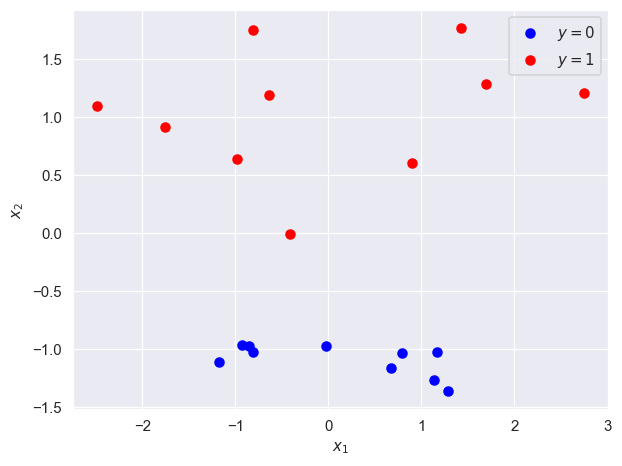

In [8]:
#function for generating synthetic data, set your student ID as the random seed. (keep it)
student_ID = 1438674
# student_ID = 2026
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 108

# Note: this problem defined "d"-features.
X, y = make_classification(n_samples = 20, n_features = 2, n_informative=2, n_redundant=0, random_state=student_ID)
X_b = np.column_stack((np.ones_like(y), X))

plt.scatter(X[y==0,0], X[y==0,1], color='b', label="$y = 0$")
plt.scatter(X[y==1,0], X[y==1,1], color='r', label="$y = 1$")
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.show()

Converged in 10000 iterations
Learned weights: [ 4.9134849  -0.66775519 12.63063028]
Final risk: 0.000505


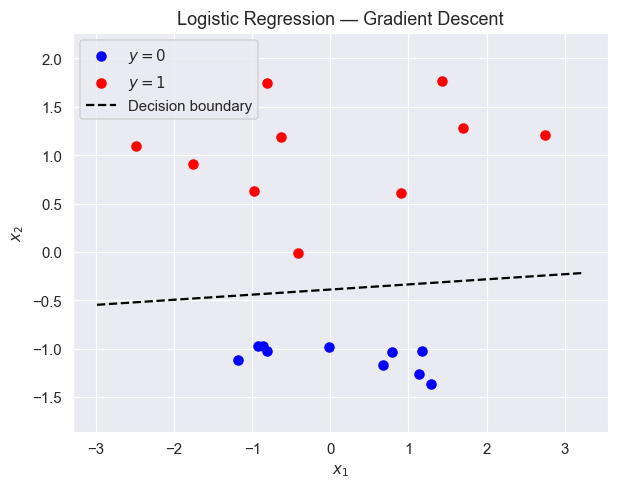

In [9]:
#Your answer

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def risk(X, y, w):
    """Compute empirical risk (cross-entropy loss).
    X : (n_samples, n_features) i.e. n * d
    y : (n_samples,) i.e. n * 1
    w : (n_features,) i.e. d * 1
    """
    mu = sigmoid(X @ w) # @ operator for matrix-vector multiplication
    # clip to avoid log(0)
    mu = np.clip(mu, 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(mu) + (1 - y) * np.log(1 - mu))

def grad_risk(X, y, w):
    """Compute gradient of empirical risk."""
    mu = sigmoid(X @ w)
    return X.T @ (mu - y) / len(y)

def update_weight_gd(X, y, w, lr=1.0, **kwargs):
    """Gradient descent weight update."""
    return w - lr * grad_risk(X, y, w)

def fit_logistic(X, y, w_init=None, max_iter=100, tol=1e-9,
                 update_weight=update_weight_gd, **kwargs):
    """Fits a binary logistic regression model according to the given training
    data

    Parameters
    ----------
    X : array of shape (n_samples, n_features)
        Feature matrix. The matrix must contain a constant column to
        incorporate a non-zero bias.

    y : array of shape (n_samples,)
        Response relative to `X`. Binary classes must be encoded as 0 and 1.

    w_init : array of shape (n_features,) default=None
        Initial guess for the weights vector. Defaults to a vector of
        zeroes.

    max_iter : int, default=100
        Maximum number of iterations

    tol : float, default=1e-9
        Stop when the inf-norm of the gradient falls below this value.

    update_weight : callable, default=update_weight_gd
        Callable that performs a weight update. Must have signature
        (X, y, w, **kwargs). Defaults to GD.

    **kwargs :
        Keyword arguments passed to `update_weight`.

    Returns
    -------
    w_history : list of arrays of shape (n_features,)
        History of weight vectors
    """
    if w_init is None:
        w = np.zeros(X.shape[1])
    else:
        w = w_init.copy()

    w_history = [w.copy()]

    for _ in range(max_iter):
        g = grad_risk(X, y, w)
        if np.max(np.abs(g)) <= tol:
            break
        w = update_weight(X, y, w, **kwargs)
        w_history.append(w.copy())

    return w_history

# --- Fit the model ---
w_history = fit_logistic(X_b, y, max_iter=10000, tol=1e-9, lr=1.0)
w_learned = w_history[-1]
print(f'Converged in {len(w_history)-1} iterations')
print(f'Learned weights: {w_learned}')
print(f'Final risk: {risk(X_b, y, w_learned):.6f}')

# --- Plot decision boundary ---
def plot_decision_boundary(X, y, w):
    plt.scatter(X[y==0, 0], X[y==0, 1], color='b', label='$y = 0$')
    plt.scatter(X[y==1, 0], X[y==1, 1], color='r', label='$y = 1$')

    # Decision boundary: w0 + w1*x1 + w2*x2 = 0  =>  x2 = -(w0 + w1*x1)/w2
    x1_range = np.linspace(X[:,0].min() - 0.5, X[:,0].max() + 0.5, 200)
    x2_boundary = -(w_learned[0] + w_learned[1] * x1_range) / w_learned[2]
    plt.plot(x1_range, x2_boundary, 'k--', label='Decision boundary') # 'k--' for black dashed line

    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.ylim(X[:,1].min() - 0.5, X[:,1].max() + 0.5)
    plt.legend()
    plt.title('Logistic Regression — Gradient Descent')
    plt.show()

    return

plot_decision_boundary(X, y, w_learned)


### 5.3 — Validation Against scikit-learn 

To verify correctness, compare the weights vector of your implementation with scikit-learn's implementation.

By default, scikit-learn includes **L2 regularization**.
You can disable it by setting ` {penalty = None}.`

1. The weights vector of your implementation 
2. The weights vector of scikit-learn's implementation 

In [10]:
# 1. Weights from our implementation
print('Our weights:    ', w_learned)


Our weights:     [ 4.9134849  -0.66775519 12.63063028]


sklearn weights: [ 6.28817133 -0.33419063 15.05355598]

Max absolute difference: 2.422926e+00


/Users/remilia/Documents/【ELEN90083】Coding/Working/.venv_remi/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


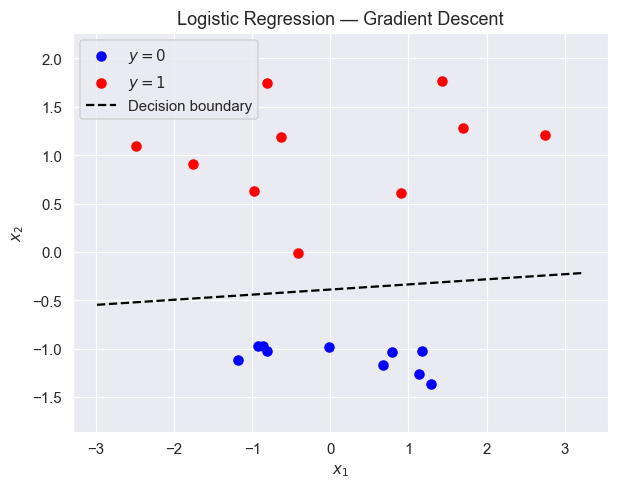

In [11]:
# 2. Weights from scikit-learn
from sklearn.linear_model import LogisticRegression

# Set C=np.inf to disable regularization, equivalent to `penalty=None` in older versions of sklearn (not supported in newer versions).
# clf stands for "classifier"
clf = LogisticRegression(C=np.inf, max_iter=10000)
clf.fit(X, y)

# sklearn stores intercept separately; stack to match our format [bias, w1, w2]
w_sklearn = np.concatenate([[clf.intercept_[0]], clf.coef_[0]])
print('sklearn weights:', w_sklearn)

print(f'\nMax absolute difference: {np.max(np.abs(w_learned - w_sklearn)):.6e}')

# --- Plot decision boundary ---
plot_decision_boundary(X, y, w_sklearn)